In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
df=pd.read_csv('/content/goog1.csv')
df.head(5)

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


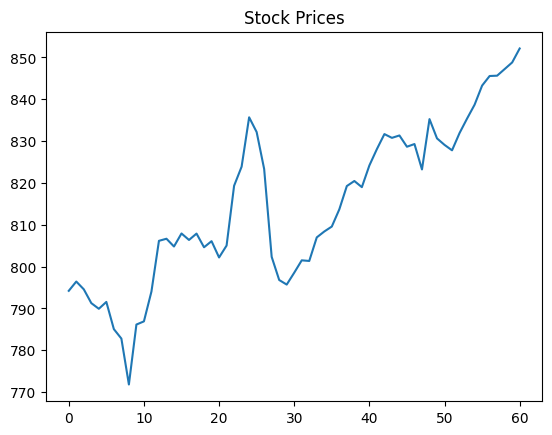

In [35]:
data=df['Close']
plt.plot(data)
plt.title("Stock Prices")
plt.show()

In [36]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
data=scaler.fit_transform(np.array(data).reshape(-1,1))

In [37]:
train_size=int(len(data)*0.80)
train=data[:train_size]
test=data[train_size:]

In [38]:
def create_data(dataset, step=4):
    X, y = [], []

    for i in range(len(dataset)-step):
        X.append(dataset[i:i+step])
        y.append(dataset[i+step])

    return np.array(X), np.array(y)

X_train, y_train = create_data(train)
X_test, y_test   = create_data(test)

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, input_shape=(X_train.shape[1],1)))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
model.compile(optimizer='adam', loss='mse')

In [42]:
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.2449
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2159
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1880
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1627
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1396
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1186
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0995 
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0823
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0671
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0529 


In [43]:
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - loss: 0.1807


0.18070857226848602

In [44]:
y_pred = model.predict(X_test)

# Convert back to original values
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


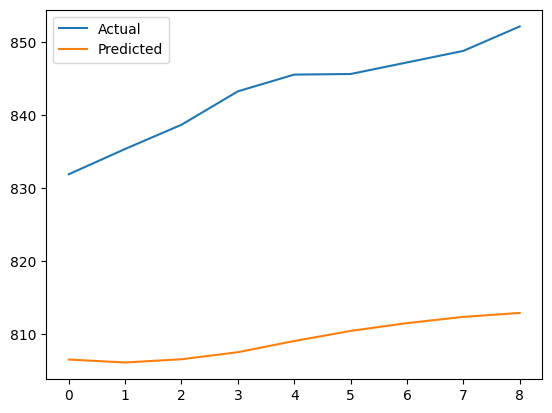

In [45]:
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

In [46]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 33.89562302300347
